<a href="https://colab.research.google.com/github/RiyaDhami13/ARDINUO/blob/main/netflix_viz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub
path = kagglehub.dataset_download("padmapriyatr/netflix-titles")

100%|██████████| 1.34M/1.34M [00:00<00:00, 2.50MB/s]

Extracting files...


In [3]:
import kagglehub
path = kagglehub.dataset_download("shivamb/netflix-shows")

Using Colab cache for faster access to the 'netflix-shows' dataset.


In [1]:
from google.colab import files
files.upload()

KeyboardInterrupt: 

In [ ]:
!pip install matplotlib-venn

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
%matplotlib inline

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import kagglehub
from kagglehub import KaggleDatasetAdapter


sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)

# Load dataset
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "shivamb/netflix-shows",
  "netflix_titles.csv"
)

print(f"✅ Data Loaded: {df.shape[0]} rows, {df.shape[1]} columns\n")
display(df.head())

Using Colab cache for faster access to the 'netflix-shows' dataset.
✅ Data Loaded: 8807 rows, 12 columns



,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
#basic dataset info
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


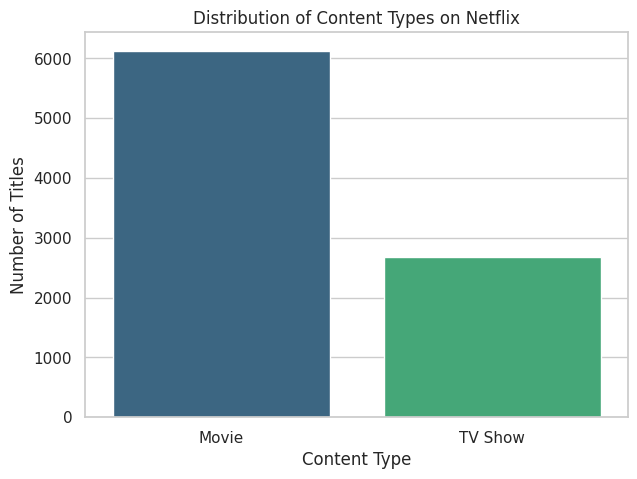

In [ ]:
#movies vs tv shows count
df['type'].value_counts()

plt.figure(figsize=(7, 5))
sns.countplot(x='type', data=df, palette='viridis')
plt.title('Distribution of Content Types on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.show()


In [ ]:
#most common countries in this
df['country'].value_counts().head(10)


,count
country,
United States,2818
India,972
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124
Mexico,110


***United States is the country that provides most tv shows and movies for this platform.***

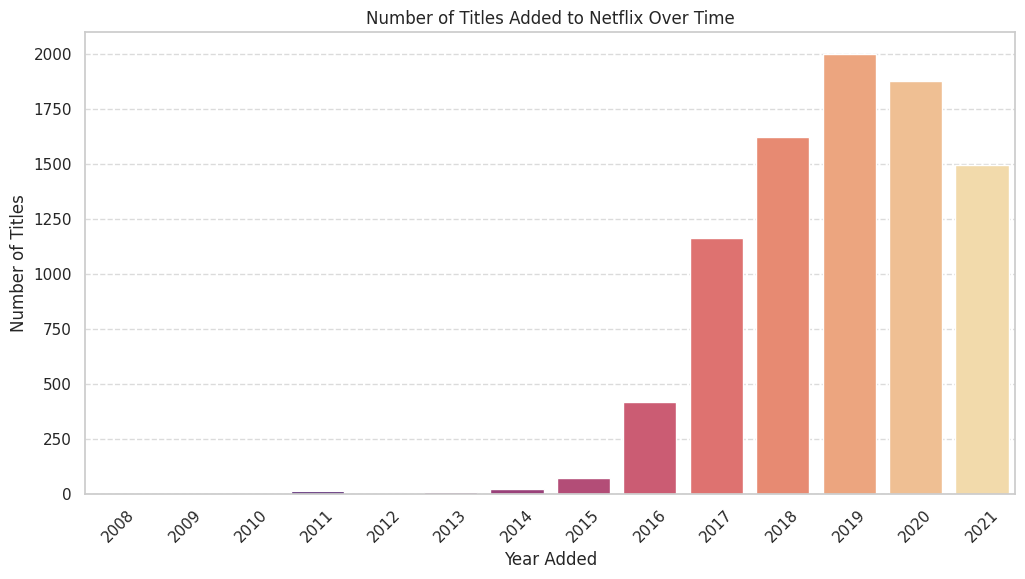

In [ ]:
# Convert 'date_added' to datetime objects
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year.fillna(0).astype(int)

# Filter out rows where 'year_added' is 0
df_valid_years = df[df['year_added'] > 0]

plt.figure(figsize=(12, 6))
sns.countplot(x='year_added', data=df_valid_years, palette='magma')
plt.title('Number of Titles Added to Netflix Over Time')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


***In 2019 A.D. , most new content was added to Netflix from 2008.:***

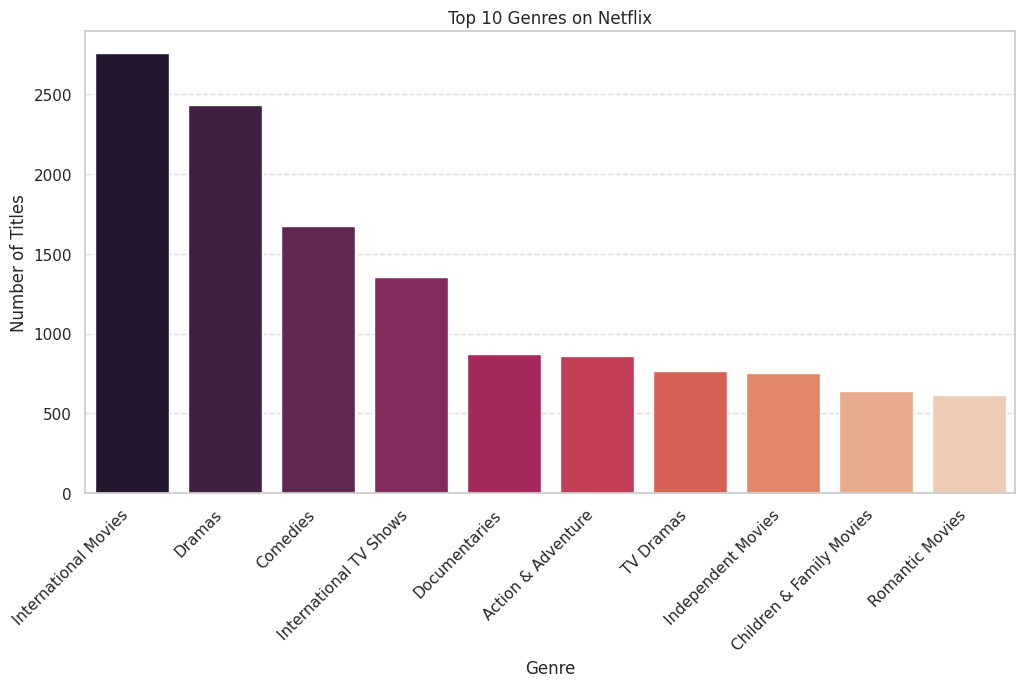

In [ ]:
# Handle missing genre values and split multiple genres
genres_df = df.dropna(subset=['listed_in']).copy() # Creating  a copy
genres_df['listed_in'] = genres_df['listed_in'].apply(lambda x: [g.strip() for g in x.split(',')])
all_genres = genres_df.explode('listed_in')

# Get top 10 genres
top_genres = all_genres['listed_in'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_genres.index, y=top_genres.values, palette='rocket')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()